# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df.shape

(10886, 19)

In [4]:
df.index.to_series().diff().value_counts().head()

datetime
0 days 01:00:00     10820
0 days 02:00:00        36
12 days 01:00:00       13
11 days 01:00:00        8
0 days 03:00:00         5
Name: count, dtype: int64

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [5]:
daily_count = df['count'].resample('D').sum()
daily_count.head()

datetime
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
Freq: D, Name: count, dtype: int64

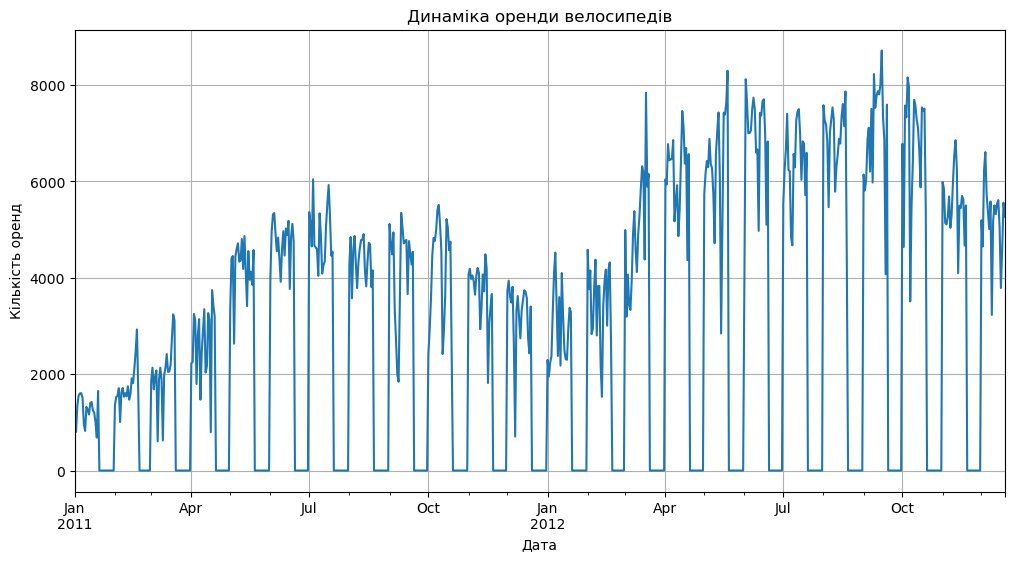

In [13]:
daily_count.plot(
    figsize=(12, 6), 
    title='Динаміка оренди велосипедів', 
    grid=True,
    xlabel='Дата',
    ylabel='Кількість оренд'
);

1. Графік має заломи, тому що ми дивимось на поденну динаміку оренди. на графіку нижче представлений графік з деталізацієй за тиждень, там залому вже не такі виражені
2. Загальні тенденції: видно, що в цілому з початку 2011 року по кінець 2021 року динаміка оренди позитивна, кількість оренд збіьшується
3. На графіку помітні сезонні коливання: в теплу пору року оренд суттєво більше, аніж в холодний сезон
4. Аномаії: аномально низькі значення - це 0, можливо - вихідні, свята, закриття сервісу; аномально високі піки фіксуються влітку - під час сезонної активності

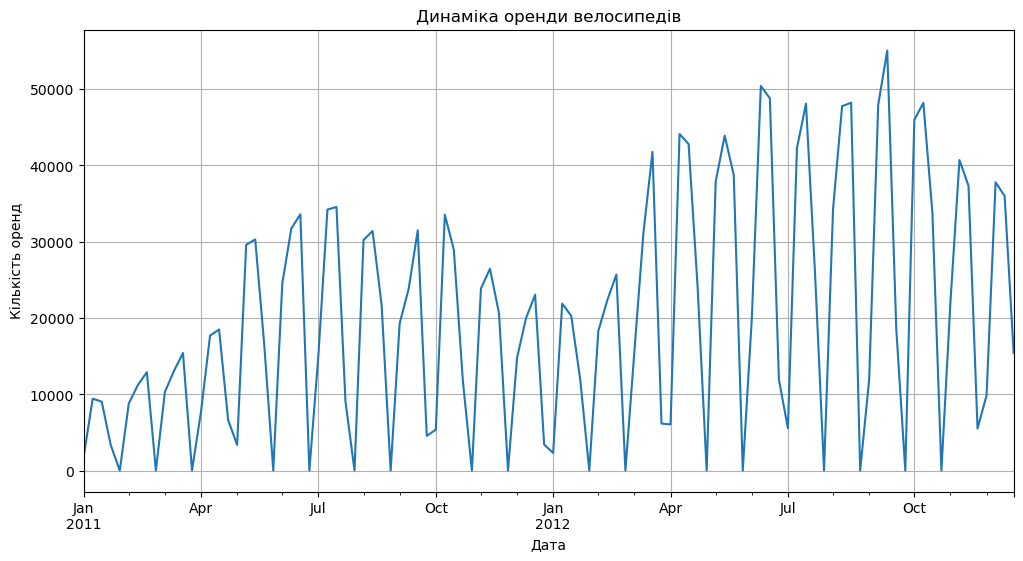

In [14]:
weekly = df['count'].resample('W').sum()
weekly.plot(
    figsize=(12, 6), 
    title='Динаміка оренди велосипедів', 
    grid=True,
    xlabel='Дата',
    ylabel='Кількість оренд'
);


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

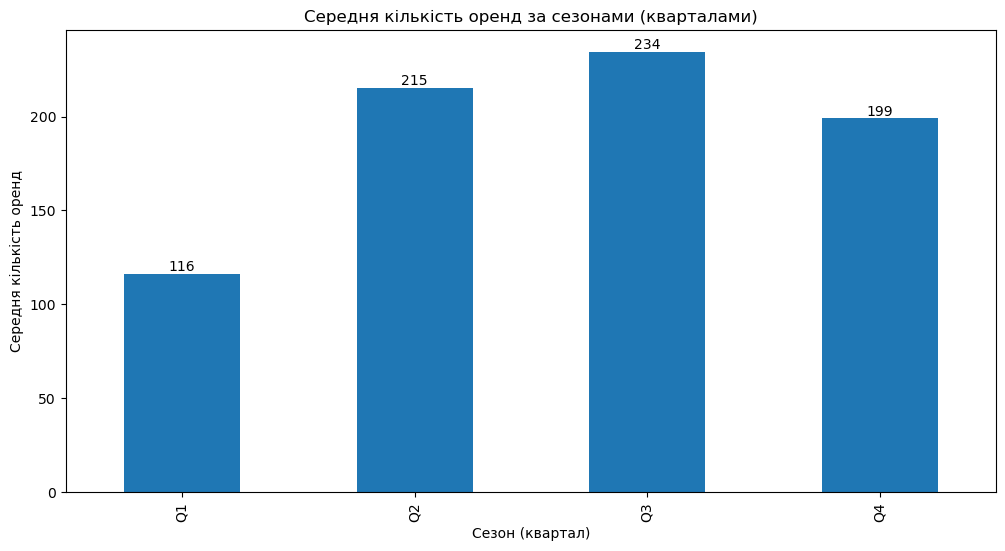

In [22]:
season_map = {
    1: 'Q1',
    2: 'Q2',
    3: 'Q3',
    4: 'Q4'
}

season_avg = df.groupby('season')['count'].mean()
season_avg.index = season_avg.index.map(season_map)

ax = season_avg.plot.bar(
    figsize=(12, 6),
    title='Середня кількість оренд за сезонами (кварталами)',
    xlabel='Сезон (квартал)',
    ylabel='Середня кількість оренд',
)

for patch in ax.patches:
    height = patch.get_height()
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        height,
        f"{height:.0f}",
        ha='center',
        va='bottom'
    )

plt.show()

1. У який квартал найбільша середня кількість оренд?
Найбільше оренд - у Q3 (третій квартал): 234 оренди.

2. Чому так відбувається - сезонна закономірність
Третій квартал — це літо, у цей період: тепла й стабільна погода, багато людей відпочивають та більше бувають на вулиці, зростає активність туристів, дощів менше, ніж у сезон мусонів, найкомфортніший час для катання на велосипеді. Тому попит логічно максимальний.

3. У скільки разів Q3 відрізняється від найслабшого кварталу?
Найменше оренд у Q1: 116 оренд.
Розрахунок: 234/116≈2.02
Тобто в Q3 люди беруть велосипеди приблизно в 2 рази частіше, ніж у Q1.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


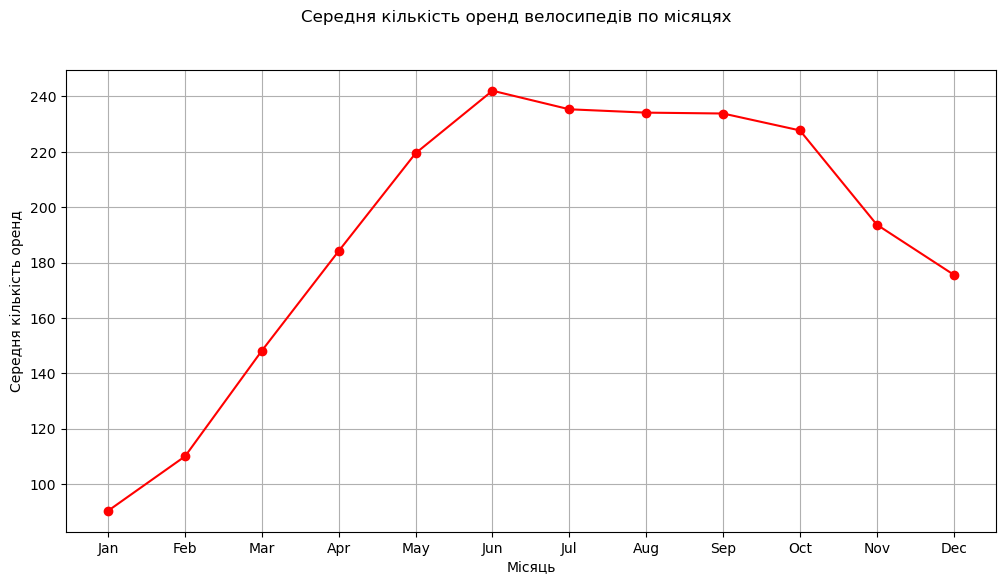

In [30]:
monthly_avg = df.groupby('month')['count'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_avg.plot(
    figsize=(12, 6),
    marker='o',
    color='red',
    subplots=True,
    title='Середня кількість оренд велосипедів по місяцях',
    xlabel='Місяць',
    ylabel='Середня кількість оренд',
    grid=True
)

plt.xticks(monthly_avg.index, [month_names[m-1] for m in monthly_avg.index])

plt.show()

1. У які місяці спостерігається пік та спад оренди?
Пік оренди:
Червень (Jun) — найвищий показник (~240).Також високі значення у липні–вересні (Jul–Sep).
Спад оренди:
Січень (Jan) — найнижчий (~90).Також низькі значення у лютому (Feb).

3. Чи збігається це з результатами попереднього завдання (квартали)?
Так, повністю збігається

3. Як може впливати клімат на оренду велосипедів протягом року?
Теплі місяці → більше оренд (комфортна температура, суха погода, довший світловий день, туристичний сезон).
Холодні місяці → менше оренд (холодно, сиро, короткий день, менше поїздок на свіжому повітрі, нижча активність людей).

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

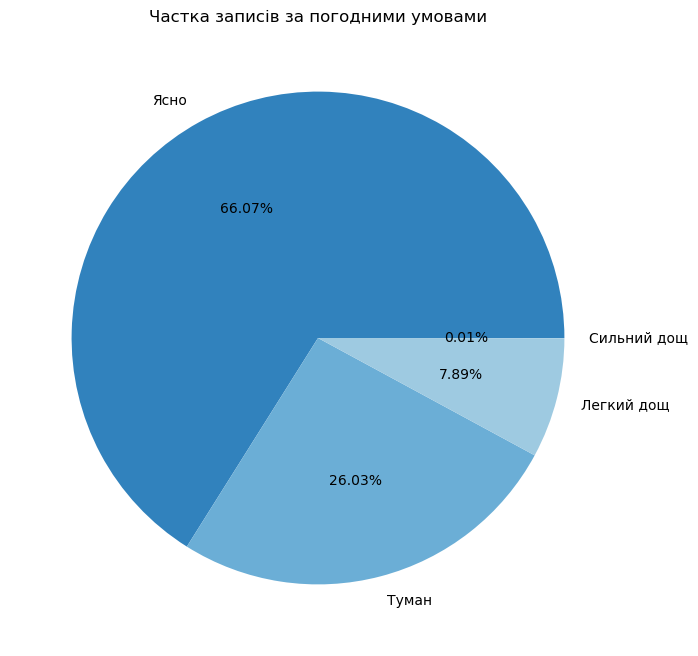

In [46]:
weather_counts = df['weather'].value_counts().sort_index()

weather_counts.plot.pie(
    figsize=(8,8),
    autopct='%1.2f%%',   
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=plt.cm.tab20c.colors,
)
plt.show()

Очікуваний результат:

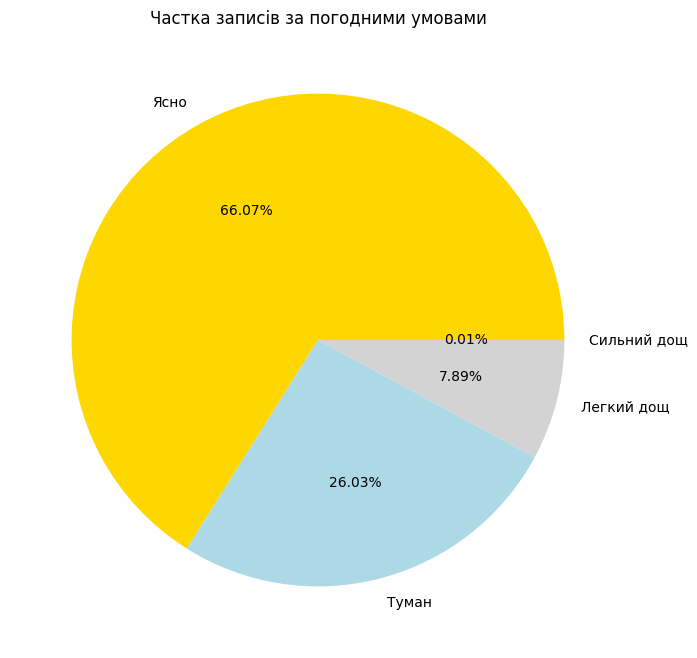

1.  В датасеті переважає ясна погода (≈66% усіх записів)
2.  Частка днів з сильним дощем ≈0,01%
3.  Попит на оренду напряму залежить від погоди: краща погода → більше оренд, гірша → менше.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

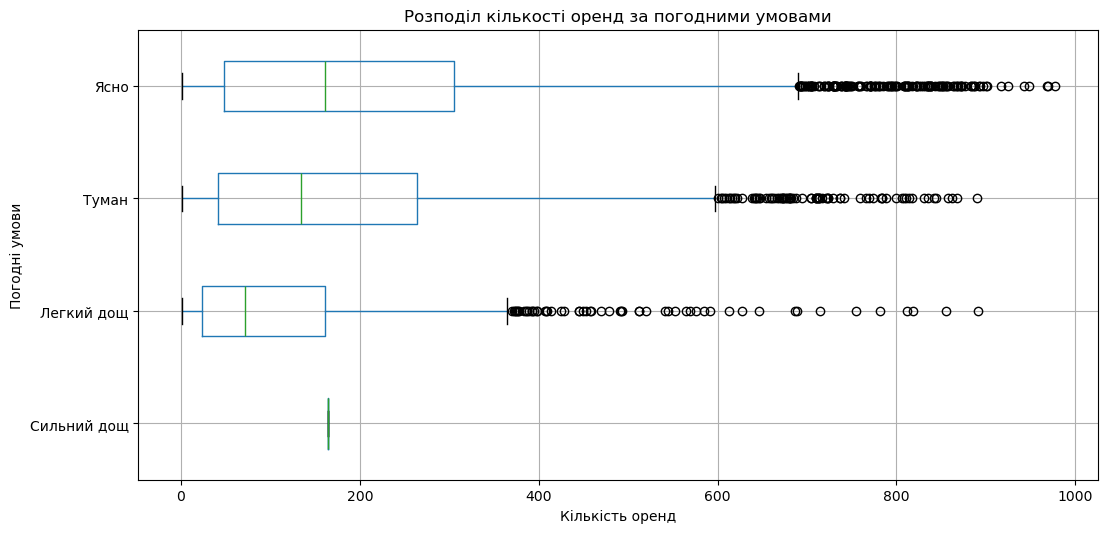

In [56]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}

df['weather_name'] = df['weather'].map(weather_labels)

df['weather_name'] = pd.Categorical(
    df['weather_name'],
    categories=['Сильний дощ', 'Легкий дощ', 'Туман', 'Ясно'],
    ordered=True
)

df.boxplot(
    figsize=(12, 6),
    column='count',
    by='weather_name',
    vert=False,
    grid=True
)

plt.title('Розподіл кількості оренд за погодними умовами')
plt.suptitle('')
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')

plt.show()

1. Найбільший розкид (ширина коробки + довгі “вуса”) спостерігається при ясній погоді

2. Чи є викиди (outliers)? При якій погоді?
Так, викиди є, і дуже багато. Найбільше викидів при: ясній погоді, тумані, легкому дощі.
Вони виглядають як чорні кружечки справа — це дні з надзвичайно великою кількістю оренд.
При сильному дощі даних мало → коробка вузька; викиди теж можливі, але рідкісні
3. При якій погоді медіанне значення оренди найвище?
Медіана - це зелена вертикальна лінія.Найвища медіана спостерігається при ясній погоді. Це означає, що типове (середньостатистичне) значення оренди в ясні дні - найвище серед усіх погодних умов.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

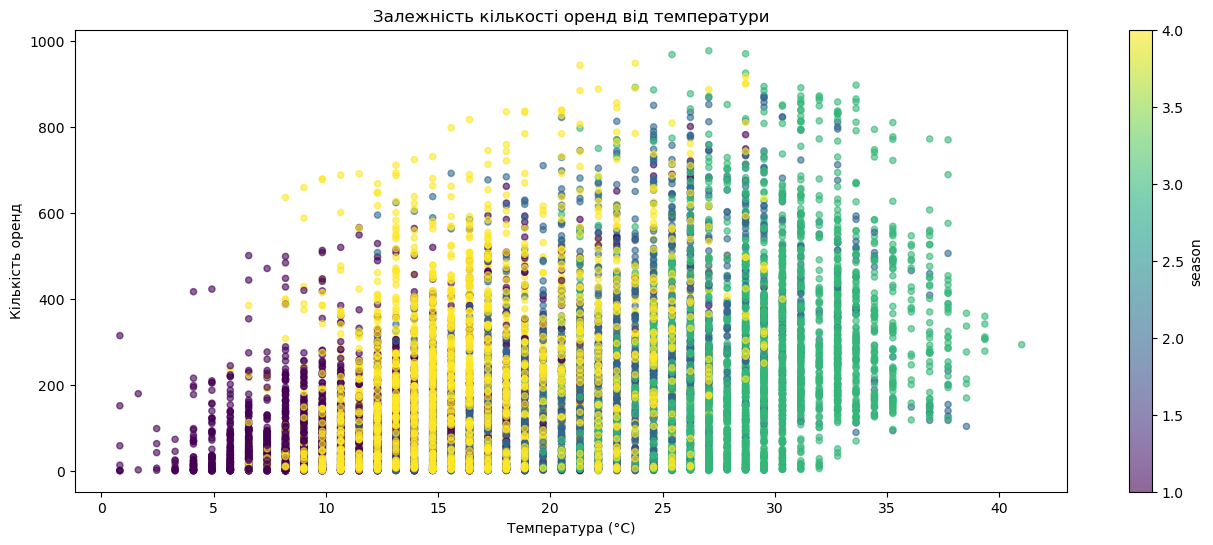

In [75]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    figsize=(16, 6),
    alpha=0.6,
    title='Залежність кількості оренд від температури',
    xlabel='Температура (°C)',
    ylabel='Кількість оренд'
)

plt.show()

Так. Температура і кількість оренд пов’язані позитивно: тепліші дні сприяють значно більшій кількості поїздок.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

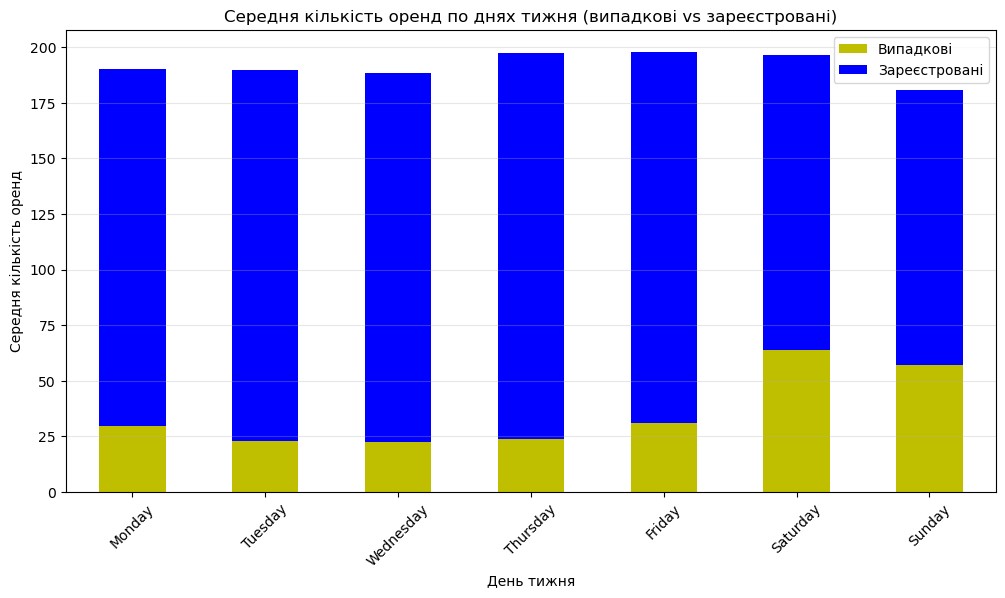

In [77]:
weekday_avg = df.groupby('weekday')[['casual', 'registered']].mean()

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = weekday_avg.loc[order]

weekday_avg.plot.bar(
    stacked=True,
    figsize=(12, 6),
    color=['y', 'b'],  
    title='Середня кількість оренд по днях тижня (випадкові vs зареєстровані)',
    xlabel='День тижня',
    ylabel='Середня кількість оренд'
)

plt.grid(axis='y', alpha=0.3)
plt.legend(['Випадкові', 'Зареєстровані'])
plt.xticks(rotation=45)
plt.show()

In [ ]:
Зареєстровані користувачі активно беруть велосипеди у будні (поїздки на роботу/навчання), а випадкові — переважно у вихідні (відпочинок).